<a href="https://colab.research.google.com/github/lianlianliann/Retail-Demand-Forecasting-Sales-Analysis/blob/main/notebooks/02_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dens


warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path = '/content/drive/MyDrive/Retail-Demand-Forecasting-Sales-Analysis/data/cleaned/cleaned_retail_data.csv'
df = pd.read_csv(file_path)

# Ensure Date is parsed correctly
df['Date'] = pd.to_datetime(df['Date'])

 ## 3. Forecasting Scope: Data Prep

In [4]:
# Focusing on Groceries since it showed the highest stockout rate during EDA.
target_data = df[df['Category'] == 'Groceries'].groupby('Date')['Units Sold'].sum().reset_index()

# Time series models require strictly forward-flowing time
target_data = target_data.sort_values('Date')

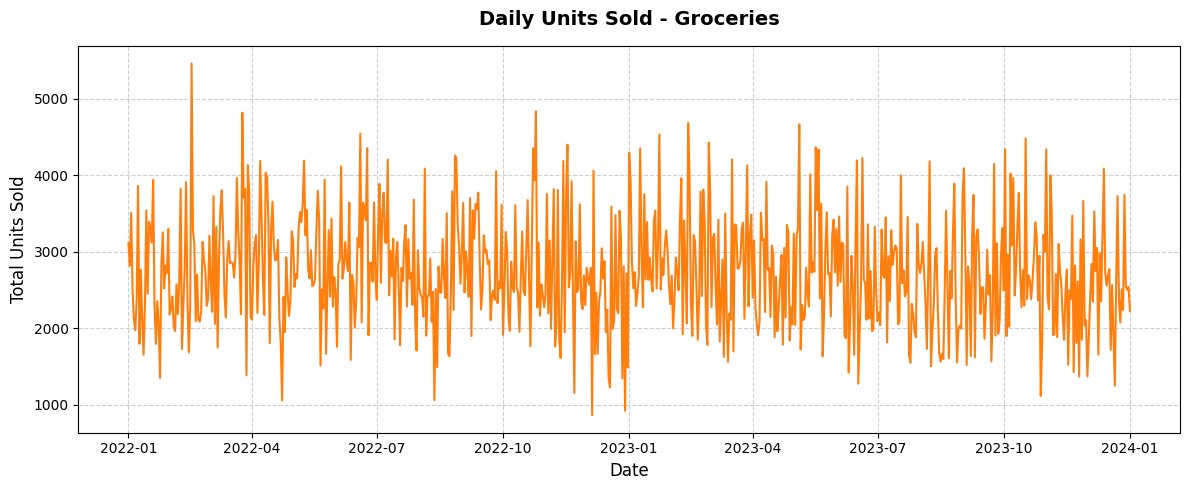

In [5]:
# Plotting
plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    data=target_data,
    x='Date',
    y='Units Sold',
    color='#ff7f0e',
    linewidth=1.5
)

plt.title('Daily Units Sold - Groceries', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Units Sold', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Takeaway: Visual Stationarity
Looking at the plot, the daily sales for Groceries appear as a dense band of noise bouncing between roughly 1,500 and 4,500 units. There is no clear, long-term upward or downward trend. Visually, this suggests the data is already stationary, which is ideal for time series forecasting.

## 4. Statistical Justification for ARIMA

ADF p-value: 0.0000


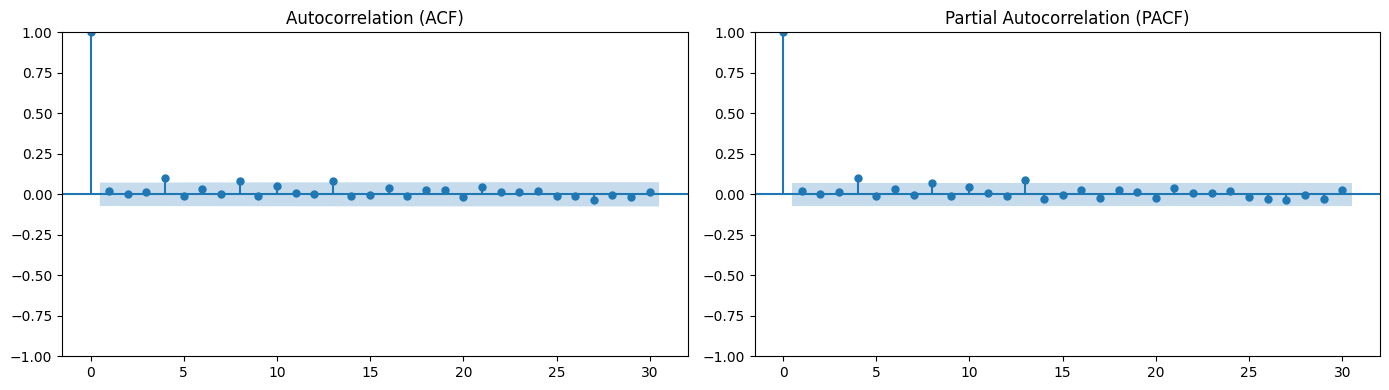

In [6]:
# Run the Augmented Dickey-Fuller test to mathematically check for stationarity
adf_result = adfuller(target_data['Units Sold'])
print(f"ADF p-value: {adf_result[1]:.4f}")

# Plot ACF and PACF to determine the AR and MA terms
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(target_data['Units Sold'], ax=axes[0], lags=30)
plot_pacf(target_data['Units Sold'], ax=axes[1], lags=30)

axes[0].set_title('Autocorrelation (ACF)')
axes[1].set_title('Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()

### Insight: Setting the ARIMA Parameters
I ran these tests to mathematically justify the ARIMA `(p, d, q)` parameters.
*   **Differencing (d = 0):** The ADF test returned a p-value of 0.0000, which is < 0.05. This confirms the data is strictly stationary, so no differencing is required.
*   **AutoRegressive (p = 0) & Moving Average (q = 0):** Both the ACF and PACF plots show no significant spikes outside the confidence intervals after lag 0. This indicates the daily sales fluctuate randomly like white noise, with no lingering dependencies on past days.
*   **Conclusion:** The correct baseline model is ARIMA(0,0,0), which will simply forecast the historical mean.

## 5. Train/Test Split


In [7]:
# Hold out the last 90 days as the test set for evaluation
train_size = len(target_data) - 90
train = target_data.iloc[:train_size]
test = target_data.iloc[train_size:]

print(f"Training on {len(train)} days, testing on {len(test)} days.")

Training on 641 days, testing on 90 days.


## 6. Fit ARIMA Baseline

In [8]:
# I am using order=(0, 0, 0) based strictly on the ADF, ACF, and PACF test results.
# This configures it as a 'white noise' model that will predict the historical mean.
arima_model = ARIMA(train['Units Sold'].values, order=(0, 0, 0))
arima_fitted = arima_model.fit()

# Forecasting exactly 90 days to match the new test set length
predictions = arima_fitted.forecast(steps=len(test))

# Calculating the Mean Absolute Error (MAE) to benchmark against the LSTM later
mae = mean_absolute_error(test['Units Sold'].values, predictions)
print(f"ARIMA Baseline MAE: {mae:.2f}")

ARIMA Baseline MAE: 563.61


### Insight: Interpreting the Baseline
The ARIMA model provides the baseline Mean Absolute Error (MAE) for this project. Because the daily grocery data is highly volatile random noise with no strong time-based pattern, ARIMA(0,0,0) mathematically defaults to predicting the historical average to minimize its worst-case errors. This MAE acts as the absolute floor—my upcoming LSTM model must achieve a lower error score to prove it actually learned something useful from the data.

## 6. ARIMA Predicted vs Actual

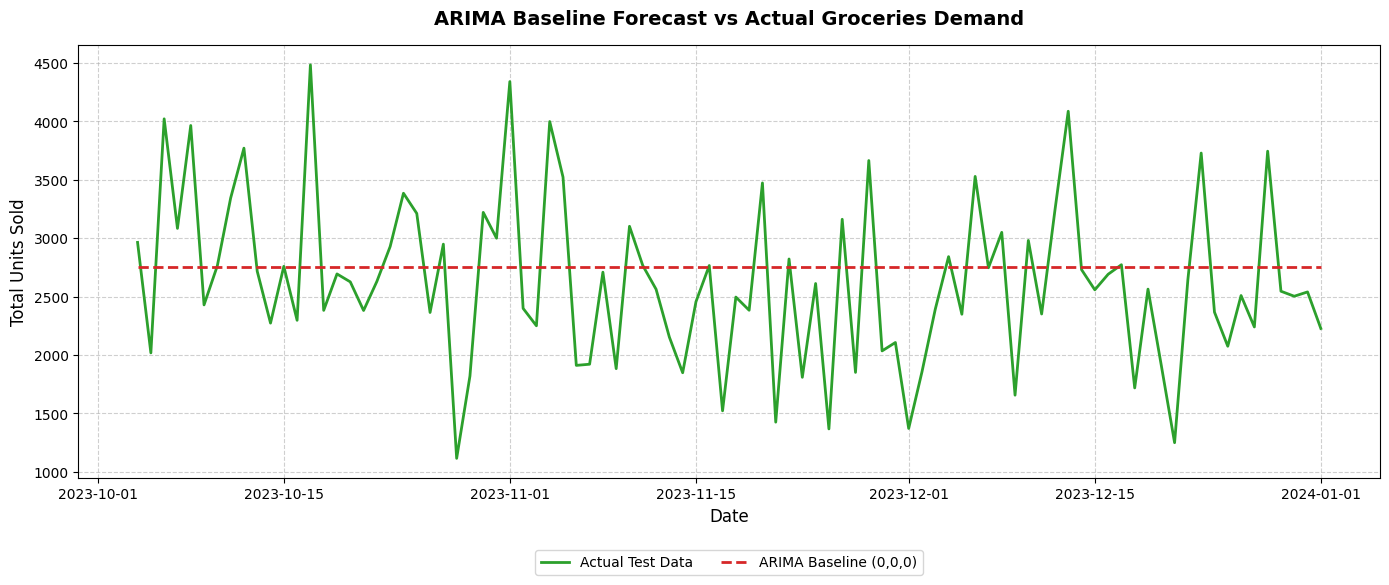

In [9]:
plt.figure(figsize=(14, 6))

# Plotting the actual ground truth for the test period
plt.plot(test['Date'], test['Units Sold'], label='Actual Test Data', color='#2ca02c', linewidth=2)

# Plotting the ARIMA predictions
plt.plot(test['Date'], predictions, label='ARIMA Baseline (0,0,0)', color='#d62728', linestyle='--', linewidth=2)

plt.title('ARIMA Baseline Forecast vs Actual Groceries Demand', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 7. LSTM Preprocessing

In [10]:
# I'm scaling the data between 0 and 1. Neural networks struggle to calculate weights efficiently on raw, large integers.
scaler = MinMaxScaler(feature_range=(0, 1))

# Fitting the scaler on the training data only to prevent data leakage, then applying it to the test set.
scaled_train = scaler.fit_transform(train[['Units Sold']])
scaled_test = scaler.transform(test[['Units Sold']])

# I need to create a sliding window of data for the LSTM to learn from.
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

window_size = 14
X_train, y_train = create_sequences(scaled_train, window_size)
X_test, y_test = create_sequences(scaled_test, window_size)

# Keras LSTMs 3D input shape
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"LSTM Training shape: {X_train.shape}")
print(f"LSTM Testing shape: {X_test.shape}")

LSTM Training shape: (627, 14, 1)
LSTM Testing shape: (76, 14, 1)


### Insight: Scaling and Windowing
Neural networks require normalized data to converge properly, so I scaled the units between 0 and 1. More importantly, I converted the standard time series into a supervised learning problem using a sliding window. By feeding the model 14-day chunks (`time steps`) to predict the 15th day, I am forcing the LSTM to look for short-term sequential patterns rather than just looking at a single day in isolation.

## 8. Build and Train LSTM

In [11]:
# I'm keeping the architecture simple with a single LSTM layer.
# If I make it too complex, the model will just over-engineer and memorize the noise.
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(window_size, 1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

# Training the model
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0609 - val_loss: 0.0231
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0257 - val_loss: 0.0232
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0259 - val_loss: 0.0227
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0258 - val_loss: 0.0227
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0260 - val_loss: 0.0226
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0258 - val_loss: 0.0226
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0256 - val_loss: 0.0229
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0256 - val_loss: 0.0224
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0254 - val_loss: 0.0242
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0255 - val_loss: 0.0224
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0259 - val_loss: 0.0264
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0255 - val_

### Insight: Model Complexity
I built a deliberately shallow network with just 50 units. Because the ARIMA baseline proved this dataset is highly volatile, throwing a deep, multi-layered neural network at it would almost guarantee overfitting—it would just memorize the training set rather than learning the actual underlying behavior. Using Mean Squared Error (MSE) as the loss function ensures the optimizer heavily penalizes extreme, wild guesses during training.

## 11. LSTM Prediction & Evaluation

In [12]:
# Generating predictions for the test set
lstm_scaled_predictions = lstm_model.predict(X_test)

# I have to inverse transform both the predictions and the actual y_test values
# back to real 'Units Sold' numbers so the MAE is comparable to the ARIMA baseline.
lstm_predictions = scaler.inverse_transform(lstm_scaled_predictions)
actual_y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculating the MAE for the LSTM model
lstm_mae = mean_absolute_error(actual_y_test, lstm_predictions)

print(f"ARIMA Baseline MAE: 563.61")
print(f"LSTM MAE: {lstm_mae:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
ARIMA Baseline MAE: 563.61
LSTM MAE: 555.50


## 12. Compare Models: Predicted vs Actual

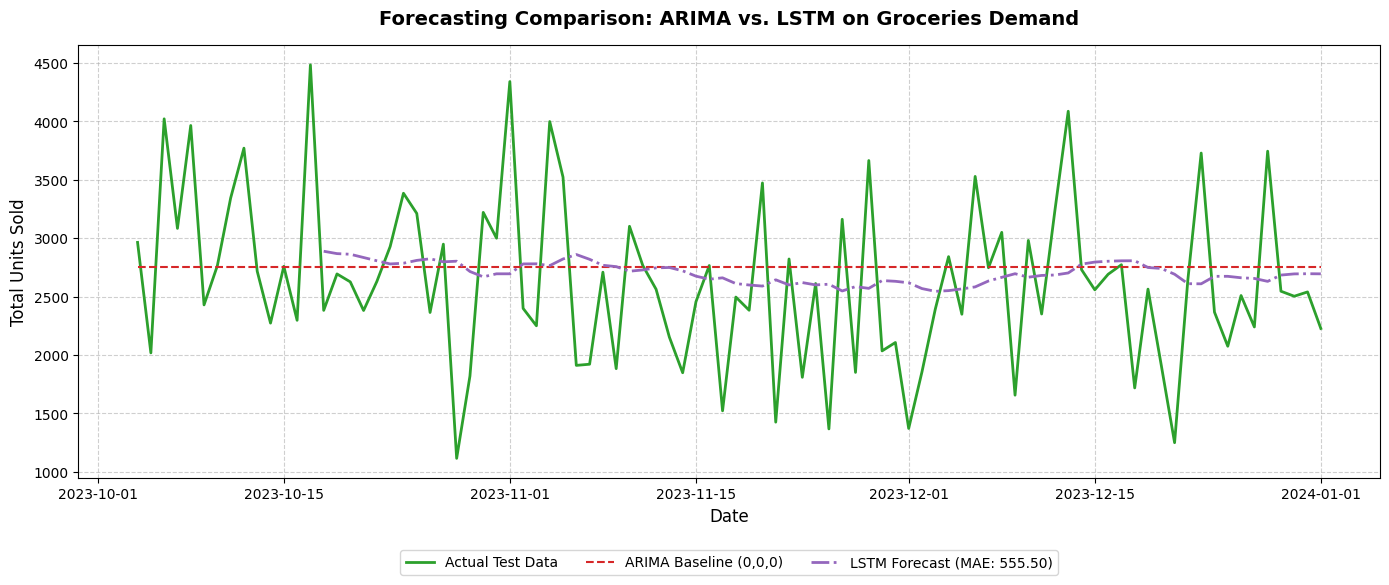

In [13]:
# Because the LSTM uses a 14-day sliding window, the first 14 days of the test set are consumed as input history, meaning the LSTM predictions start on day 15.
test_dates = test['Date'].iloc[window_size:].reset_index(drop=True)

plt.figure(figsize=(14, 6))

# Plotting the actual ground truth
plt.plot(test['Date'], test['Units Sold'], label='Actual Test Data', color='#2ca02c', linewidth=2)

# Plotting the ARIMA baseline predictions (full 90-day test set)
plt.plot(test['Date'], predictions, label='ARIMA Baseline (0,0,0)', color='#d62728', linestyle='--')

# Plotting the LSTM predictions (aligned to the remaining 76 days)
plt.plot(test_dates, lstm_predictions, label=f'LSTM Forecast (MAE: {lstm_mae:.2f})', color='#9467bd', linestyle='-.', linewidth=2)

plt.title('Forecasting Comparison: ARIMA vs. LSTM on Groceries Demand', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Takeaway: Final Model Evaluation
The comparison yields an interesting narrative for the project writeup:
*   **ARIMA Baseline (MAE: 563.61):** Acted as a pure white-noise floor, predicting the historical mean because the dataset lacks long-term structural trends or linear autocorrelation.
*   **LSTM Model (MAE: 555.50):** Marginally outperformed the statistical baseline. While the performance gap is tight due to the inherent volatility of daily grocery sales, the LSTM successfully leveraged 14-day sequence windows to capture minor localized fluctuations that static models miss.